# Limpeza dos dados


In [59]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from matplotlib.patches import Rectangle
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registra a projecao 3d)
from numpy.polynomial import Polynomial
from plotly.colors import sample_colorscale
from regressions import B_TUD, D_TUD, LBP_TUD, d_TUD
from scipy import stats

## Limpeza na base de dados


In [60]:
df = pd.read_csv("ships.csv", encoding="latin1")

raw_cols = ["DWT", "LBP", "B", "D", "d", "Vs"]

df = df[(df[raw_cols] != 0).all(axis=1)].reset_index(drop=True)
df = df[df["LBP"] < 300].reset_index(drop=True)
df = df[df["DWT"] >= 2000].reset_index(drop=True)
df = df[df["DWT"] <= 180000].reset_index(drop=True)

df.to_csv("ships2.csv", index=False, encoding="latin1")
# df.head()
df.shape

(4317, 16)

In [61]:
def dedup_by_tolerance(data, tolerances):
    key = pd.DataFrame({col: (data[col] / tol).round() * tol for col, tol in tolerances.items()})
    return data.loc[~key.duplicated()].reset_index(drop=True)

TOLERANCE_TIGHT = {"LBP": 1, "B": 0.1, "D": 0.1, "d": 0.1, "DWT": 100, "Vs": 0.01}
TOLERANCE_LOOSE = {"LBP": 5, "B": 0.5, "D": 0.5, "d": 0.5, "DWT": 500, "Vs": 0.1}

df_dedup_tight = dedup_by_tolerance(df, TOLERANCE_TIGHT)
df_dedup_loose = dedup_by_tolerance(df, TOLERANCE_LOOSE)

print(f"Original: {df.shape[0]} rows")
print(f"Deduplicated (tight): {df_dedup_tight.shape[0]} rows")
print(f"Deduplicated (loose): {df_dedup_loose.shape[0]} rows")

df = df_dedup_loose
# df.to_csv("ships_dedup_loose.csv", index=False, encoding="latin1")
df.shape

Original: 4317 rows
Deduplicated (tight): 3120 rows
Deduplicated (loose): 2513 rows


(2513, 16)

## Gráficos de dispersão


### Restrições


In [62]:
Golfo_Mex = {
    "d": 13.7,
    "Air_d": 53.0
}

Panama = {
    "B": 32.31,
    "L": 289.6,
    "d": 12.04,
    "Air_d": 57.91
}

Req_proj = {
    "Vs": 7.87,
    "DWT": 45100,
}

PORT_LIMITS = {
    "Panama": Panama,
    "Golfo Mex.": Golfo_Mex,
}

### Configurações dos gráficos


In [76]:
label_dict = {
    "B": "Breadth [m]",
    "D": "Depth [m]",
    "LBP": "Length Between Perpendiculars [m]",
    "d": "Scantling Draft [m]",
    "Air_d": "Air Draft [m]",
    "DWT": "DWT [t]",
    "Vs": "Speed [m/s]",
}

# cada entrada de SCATTER_PAIRS_GLOBAL/LOCAL pode ser:
#   ("x", "y")                                      -- sem area destacada
#   {"pair": ("x", "y"), "highlights": [{"x_range": (x0, x1), "y_range": (y0, y1),
#                                        "color": "...", "alpha": 0.15, "label": "..."}]}
# se "color" nao for informado, usa-se default_highlight_color de plot_scatter.
SCATTER_PAIRS_GLOBAL = [
    {"pair": ("DWT", "LBP"), "highlights": [{"x_range": (35100, 55100), "y_range": (150, 230), "color": "yellow", "alpha": 0.5, "label": "Área de interesse"}]},
    {"pair": ("DWT", "B"), "highlights": [{"x_range": (35100, 55100), "y_range": (25, Panama["B"]), "color": "yellow", "alpha": 0.5, "label": "Área de interesse"}]},
    {"pair": ("DWT", "D"), "highlights": [{"x_range": (35100, 55100), "y_range": (13, 20), "color": "yellow", "alpha": 0.5, "label": "Área de interesse"}]},
    {"pair": ("DWT", "d"), "highlights": [{"x_range": (35100, 55100), "y_range": (8, Panama["d"]), "color": "yellow", "alpha": 0.5, "label": "Área de interesse"}]},
    # ("DWT", "Air_d"),
    {"pair": ("DWT", "Vs"), "highlights": [{"x_range": (35100, 55100), "y_range": (15.3*0.5144-0.6, 15.3*0.5144+0.6), "color": "yellow", "alpha": 0.5, "label": "Área de interesse"}]},
    {"pair": ("DWT", "Fn"), "highlights": [{"x_range": (35100, 55100), "y_range": (0.16, 0.22), "color": "yellow", "alpha": 0.5, "label": "Área de interesse"}]},
    ("LBP", "B"),
    ("LBP", "Vs"),
    ("B", "D"),
    {"pair": ("DWT", "L/B"), "highlights": [{"x_range": (35100, 55100), "y_range": (5, 7), "color": "yellow", "alpha": 0.5, "label": "Área de interesse"}]},
    {"pair": ("DWT", "L/D"), "highlights": [{"x_range": (35100, 55100), "y_range": (8.3, 13), "color": "yellow", "alpha": 0.5, "label": "Área de interesse"}]},
    ("DWT", "L/d"),
    ("LBP", "D"),
    ("LBP", "L/B"),
    ("LBP", "B/D"),
    ("LBP", "L/D"),
    ("LBP", "d/D"),
]

SCATTER_PAIRS_LOCAL = [
    {"pair": ("DWT", "LBP"), "highlights": [{"x_range": (43000, 48000), "y_range": (170, 180), "color": "orange", "alpha": 0.3, "label": "Área de interesse"}]},
    {"pair": ("DWT", "B"), "highlights": [{"x_range": (43000, 48000), "y_range": (31, Panama["B"]), "color": "orange", "alpha": 0.3, "label": "Área de interesse"}]},
    {"pair": ("DWT", "D"), "highlights": [{"x_range": (43000, 48000), "y_range": (17, 19.2), "color": "orange", "alpha": 0.3, "label": "Área de interesse"}]},
    {"pair": ("DWT", "d"), "highlights": [{"x_range": (43000, 48000), "y_range": (11, Panama["d"]), "color": "orange", "alpha": 0.3, "label": "Área de interesse"}]},
    # ("DWT", "Air_d"),
    {"pair": ("DWT", "Vs"), "highlights": [{"x_range": (43000, 48000), "y_range": (7.45, 8.3), "color": "orange", "alpha": 0.3, "label": "Área de interesse"}]},
    {"pair": ("DWT", "Fn"), "highlights": [{"x_range": (43000, 48000), "y_range": (0.175, 0.195), "color": "orange", "alpha": 0.3, "label": "Área de interesse"}]},
    ("LBP", "B"),
    ("LBP", "Vs"),
    ("B", "D"),
    {"pair": ("DWT", "L/B"), "highlights": [{"x_range": (43000, 48000), "y_range": (5.25, 5.75), "color": "orange", "alpha": 0.3, "label": "Área de interesse"}]},
    {"pair": ("DWT", "L/D"), "highlights": [{"x_range": (43000, 48000), "y_range": (9, 11), "color": "orange", "alpha": 0.3, "label": "Área de interesse"}]},
    ("DWT", "L/d"),
    ("LBP", "D"),
    ("LBP", "L/B"),
    ("LBP", "B/D"),
    ("LBP", "L/D"),
    ("LBP", "d/D"),
]

# pares (x, y) em que a curva de regressao polinomial (DWT/LBP x dimensao) e mostrada
REGRESSION_PAIRS = {
    ("DWT", "LBP"), ("DWT", "B"), ("DWT", "D"), ("DWT", "d"), ("DWT", "Fn"),
    ("LBP", "B"), ("LBP", "D"), ("B", "D")
}

# regressoes empiricas TUD 2008 (parametro em funcao do DWT)
TUD_REGRESSIONS = {
    "LBP": LBP_TUD,
    "B": B_TUD,
    "D": D_TUD,
    "d": d_TUD,
}

# coluna -> chave usada nos dicionarios de restricao de porto (valor maximo permitido)
PORT_LIMIT_KEY_MAP = {"LBP": "L", "B": "B", "d": "d"}

# coluna -> chave usada no requisito de projeto
REQ_KEY_MAP = {"DWT": "DWT", "Vs": "Vs"}


RESTRICTION_COLORS = {
    "Panama": "tab:green",
    "Golfo Mex.": "tab:pink",
    "Req_proj": "tab:red",
    #"Suez": "tab:orange",
    #"St_Lawrence": "tab:purple",
}


### Plots


In [77]:
def format_polynomial(p, var="x", precision=4):
    """escreve a funcao ajustada (coeficientes na escala original de var) como texto."""
    coeffs = p.convert(domain=[-1, 1], window=[-1, 1]).coef
    terms = []
    for power, c in enumerate(coeffs):
        if power == 0:
            terms.append(f"{c:.{precision}g}")
        elif power == 1:
            terms.append(f"{c:+.{precision}g}*{var}")
        else:
            terms.append(f"{c:+.{precision}g}*{var}^{power}")
    return "y = " + " ".join(terms)


def r2_score(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot


def poly_candidates(x, y, max_degree=3):
    """um candidato por grau de 1 a max_degree (complexidade = grau)."""
    candidates = []
    for degree in range(1, max_degree + 1):
        p = Polynomial.fit(x, y, degree)
        r2 = r2_score(y, p(x))
        candidates.append({
            "kind": f"Polinômio grau {degree}",
            "predict": p,
            "r2": r2,
            "complexity": degree,
            "label": format_polynomial(p, var="x"),
        })
    return candidates


def log_candidate(x, y):
    """y = a + b*ln(x); valido apenas para x > 0."""
    if np.any(x <= 0):
        return None
    a, b = np.polyfit(np.log(x), y, 1)[::-1]
    predict = lambda xv: a + b * np.log(xv)
    return {
        "kind": "Logarítmica",
        "predict": predict,
        "r2": r2_score(y, predict(x)),
        "complexity": 1,
        "label": f"y = {a:.4g} + {b:.4g}*ln(x)",
    }


def sqrt_candidate(x, y):
    """y = a + b*sqrt(x); valido apenas para x >= 0."""
    if np.any(x < 0):
        return None
    a, b = np.polyfit(np.sqrt(x), y, 1)[::-1]
    predict = lambda xv: a + b * np.sqrt(xv)
    return {
        "kind": "Raiz quadrada",
        "predict": predict,
        "r2": r2_score(y, predict(x)),
        "complexity": 1,
        "label": f"y = {a:.4g} + {b:.4g}*sqrt(x)",
    }


def best_model(x, y, max_degree=3, r2_threshold=0.95):
    """dentre polinomios (grau <= max_degree), log e sqrt, escolhe o de menor
    complexidade que atinge r2_threshold; senao, o de maior R^2."""
    candidates = poly_candidates(x, y, max_degree)
    for extra in (log_candidate(x, y), sqrt_candidate(x, y)):
        if extra is not None:
            candidates.append(extra)
    candidates.sort(key=lambda c: c["complexity"])

    for c in candidates:
        if c["r2"] >= r2_threshold:
            return c
    return max(candidates, key=lambda c: c["r2"])


def highlight_area(ax, x_range=None, y_range=None, color="gold", alpha=0.15, label=None, zorder=0):
    """Desenha uma area sombreada e transparente delimitada por x_range e/ou y_range no eixo."""
    if x_range is not None and y_range is not None:
        (x0, x1), (y0, y1) = x_range, y_range
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0,
                                facecolor=color, edgecolor="none",
                                alpha=alpha, zorder=zorder, label=label))
    elif x_range is not None:
        ax.axvspan(*x_range, facecolor=color, edgecolor="none",
                   alpha=alpha, zorder=zorder, label=label)
    elif y_range is not None:
        ax.axhspan(*y_range, facecolor=color, edgecolor="none",
                   alpha=alpha, zorder=zorder, label=label)


def plot_scatter(sel_df: pd.DataFrame, pairs, reg=True, default_highlight_color="gold"):
    """pairs: lista de (x, y) ou de dicts {"pair": (x, y), "highlights": [...]}.

    cada highlight e um dict de kwargs para highlight_area; se nao tiver "color",
    usa default_highlight_color.
    """
    for entry in pairs:
        if isinstance(entry, dict):
            x, y = entry["pair"]
            highlight_specs = entry.get("highlights", [])
        else:
            x, y = entry
            highlight_specs = []

        _fig, ax = plt.subplots(figsize=(6, 5))

        # areas destacadas (opcional): faixas de x/y sombreadas e transparentes
        for spec in highlight_specs:
            highlight_area(ax, **{"color": default_highlight_color, **spec})

        ax.scatter(sel_df[x], sel_df[y], color="steelblue",
                edgecolor="steelblue", alpha=0.3, s=15)
        ax.set_xlabel(label_dict.get(x, x))
        ax.set_ylabel(label_dict.get(y, y))
        # ax.set_title(f"{x} x {y}")

        # restricoes de porto: linha tracejada no valor maximo permitido
        for name, limits in PORT_LIMITS.items():
            color = RESTRICTION_COLORS[name]
            x_key = PORT_LIMIT_KEY_MAP.get(x)
            y_key = PORT_LIMIT_KEY_MAP.get(y)
            if x_key in limits:
                ax.axvline(limits[x_key], color=color, linestyle="--", label=name)
            if y_key in limits:
                ax.axhline(limits[y_key], color=color, linestyle="--", label=name)

        # requisito de projeto: linha tracejada no valor alvo
        x_req_key = REQ_KEY_MAP.get(x)
        y_req_key = REQ_KEY_MAP.get(y)
        if x_req_key in Req_proj:
            ax.axvline(Req_proj[x_req_key], color=RESTRICTION_COLORS["Req_proj"],
                    linestyle=":", label="Requisitos de projeto")
        if y_req_key in Req_proj:
            ax.axhline(Req_proj[y_req_key], color=RESTRICTION_COLORS["Req_proj"],
                    linestyle=":", label="Requisitos de projeto")

        regression_eq = None
        if reg and (x, y) in REGRESSION_PAIRS:
            # melhor ajuste dentre polinomio (grau <= 3), logaritmico e raiz quadrada,
            # buscando R^2 >= 0.95
            x_data = sel_df[x].to_numpy(dtype=float)
            y_data = sel_df[y].to_numpy(dtype=float)
            model = best_model(x_data, y_data)
            x_line = np.linspace(x_data.min(), x_data.max(), 200)
            ax.plot(
                x_line, model["predict"](x_line), color="black", linewidth=2,
                label=f"{model['kind']} (R²={model['r2']:.3f})",
            )
            regression_eq = model["label"]

        # regressao empirica TUD 2008 (parametro em funcao do DWT)
        if x == "DWT" and y in TUD_REGRESSIONS:
            dwt_line = np.linspace(25000, 55000, 100)
            tud_values = np.array([TUD_REGRESSIONS[y](v) for v in dwt_line])
            ax.plot(dwt_line, tud_values, color="purple", linewidth=2,
                    linestyle="-.", label="Regressão TUD (2008)")

        handles, labels = ax.get_legend_handles_labels()
        if labels:
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(), by_label.keys())

        plt.tight_layout()
        plt.show()

        if regression_eq:
            print(f"{x} x {y} -> {regression_eq}")

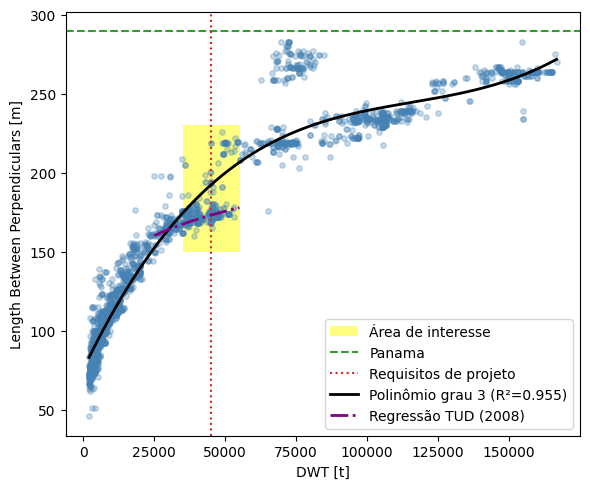

DWT x LBP -> y = 75.72 +0.003763*x -2.987e-08*x^2 +8.613e-14*x^3


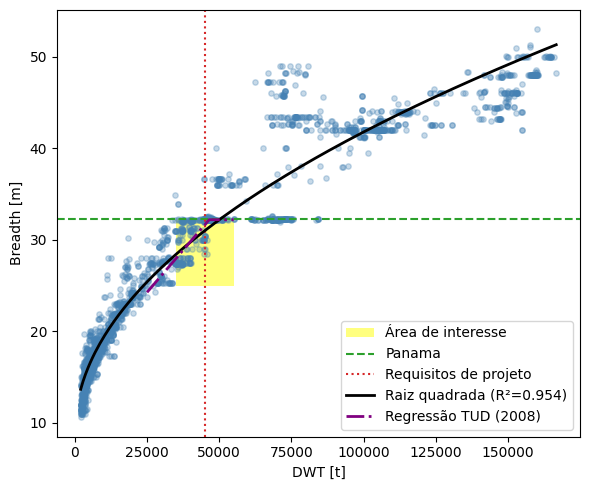

DWT x B -> y = 9.031 + 0.1036*sqrt(x)


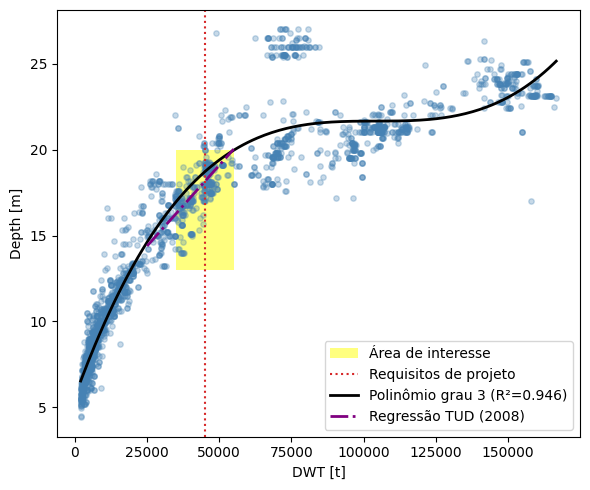

DWT x D -> y = 5.63 +0.0004612*x -4.425e-09*x^2 +1.416e-14*x^3


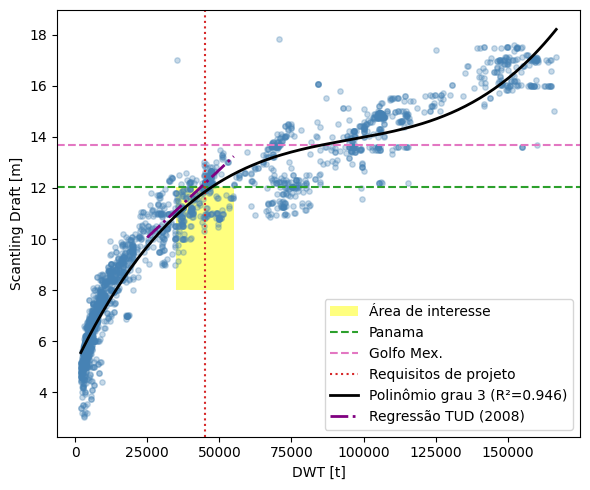

DWT x d -> y = 5.091 +0.0002359*x -2.259e-09*x^2 +7.891e-15*x^3


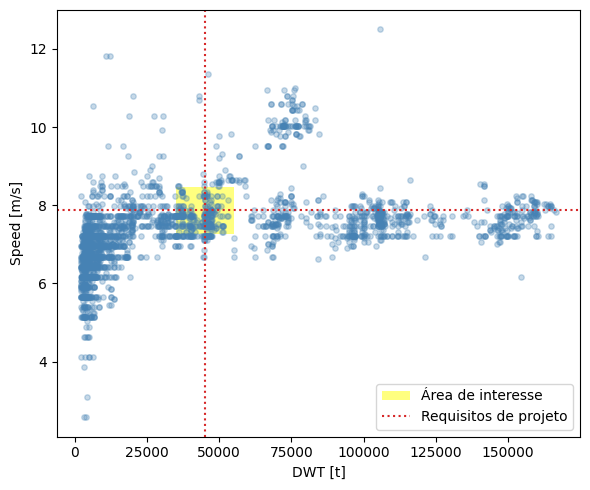

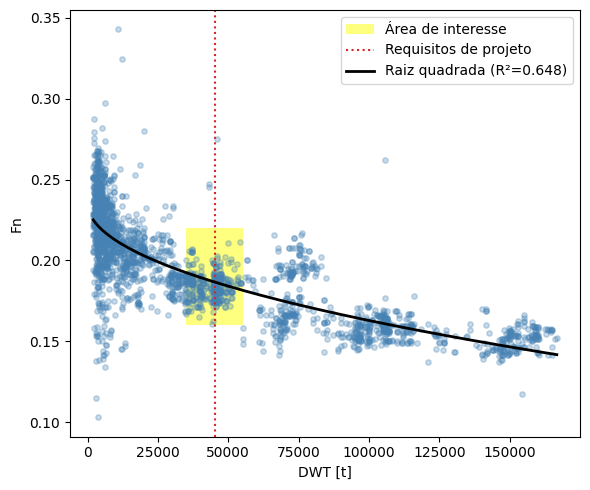

DWT x Fn -> y = 0.2353 + -0.0002292*sqrt(x)


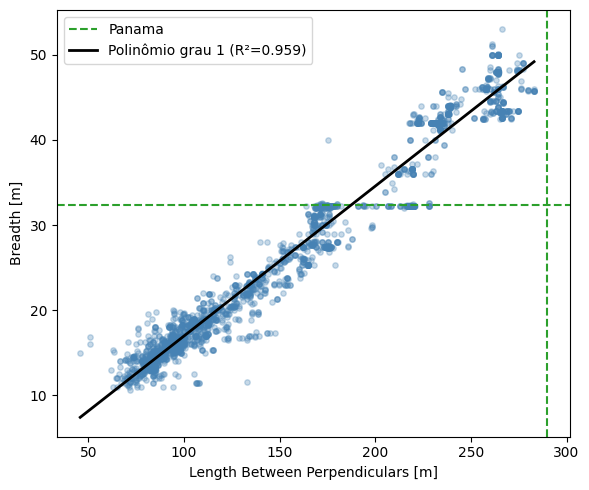

LBP x B -> y = -0.6694 +0.1762*x


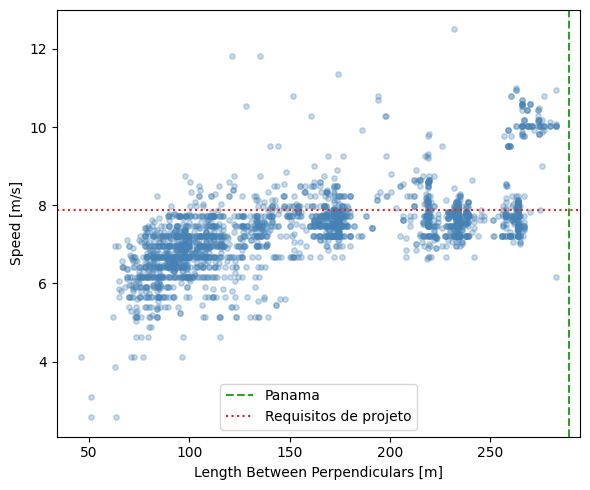

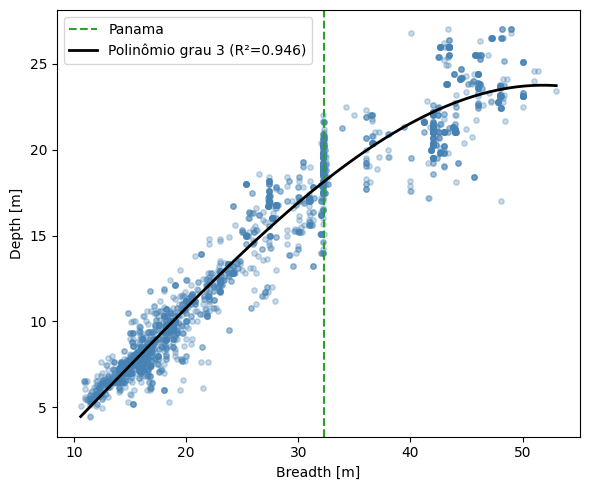

B x D -> y = -2.318 +0.5902*x +0.006346*x^2 -0.0001549*x^3


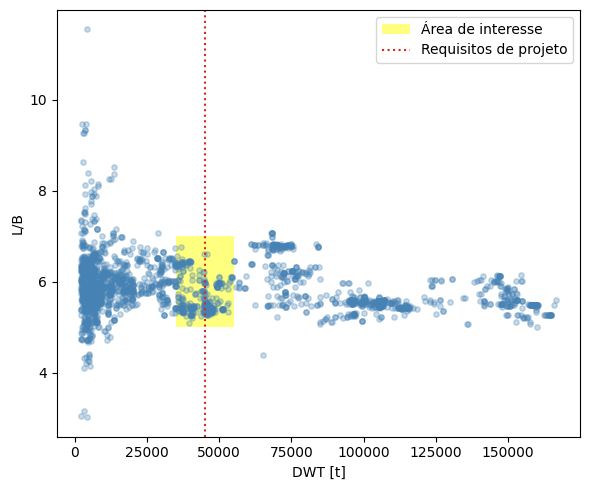

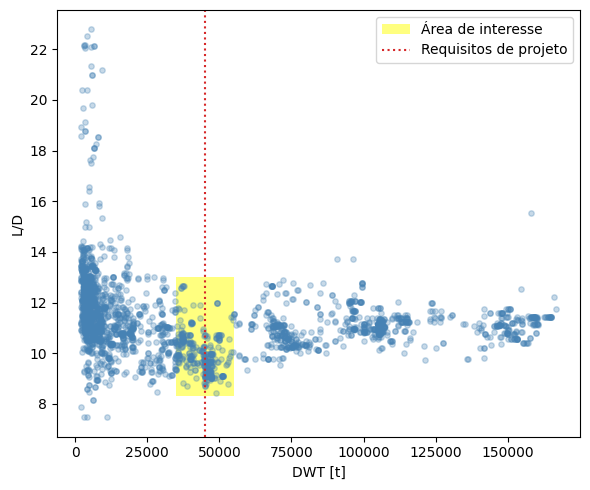

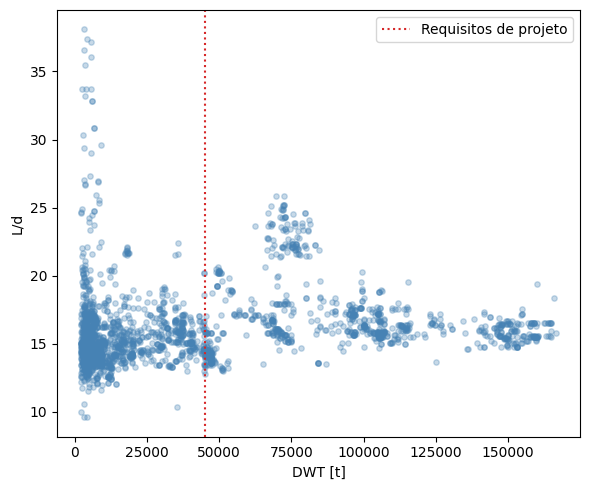

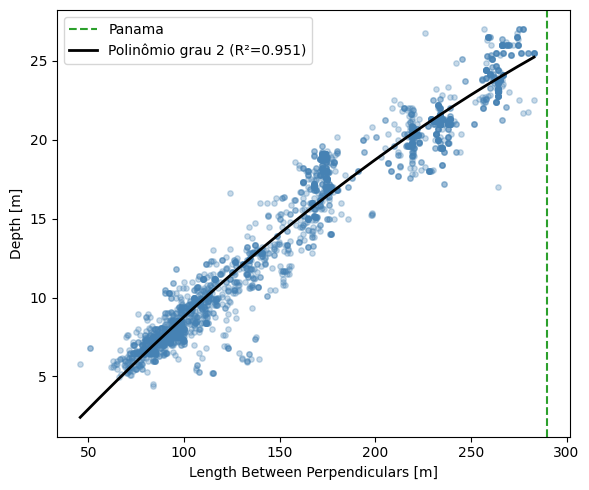

LBP x D -> y = -3.5 +0.1345*x -0.0001163*x^2


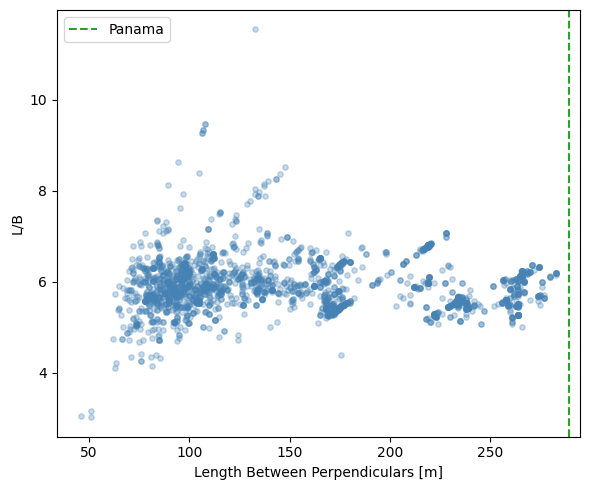

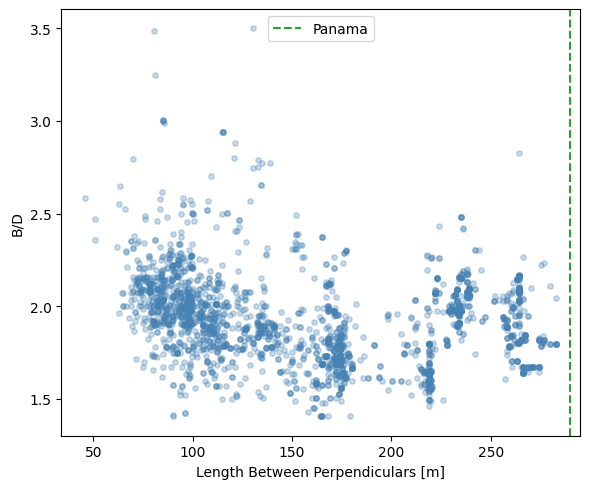

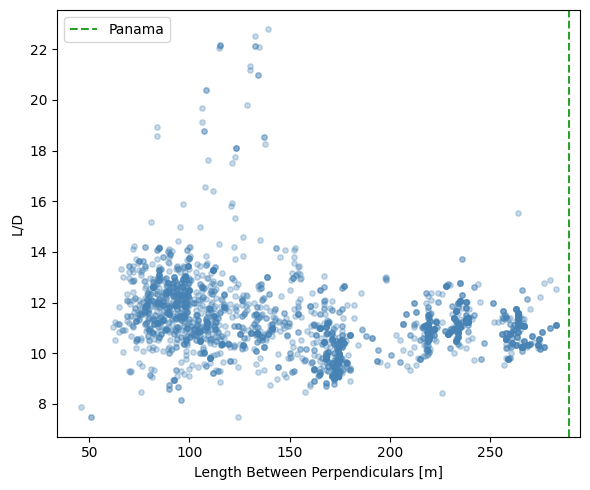

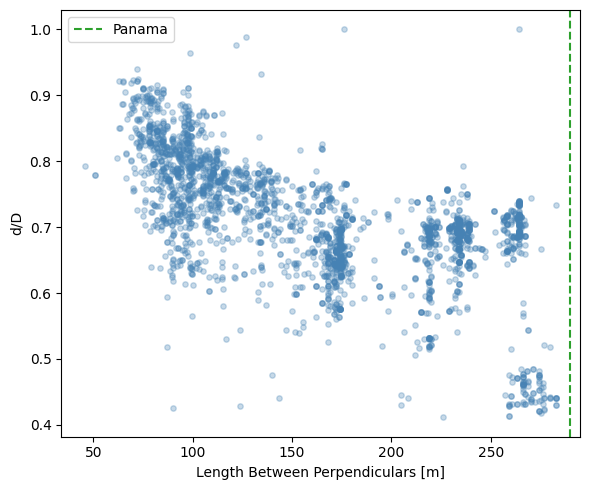

In [78]:
plot_scatter(df, SCATTER_PAIRS_GLOBAL, default_highlight_color="yellow")

In [79]:
local_DWT=[35100, 55100]
local_Vs=[Req_proj["Vs"]-0.6, Req_proj["Vs"]+0.6]

df_local = df[(df["DWT"] >= local_DWT[0]) & (df["DWT"] <= local_DWT[1]) & (df["Vs"] >= local_Vs[0]) & (df["Vs"] <= local_Vs[1])].reset_index(drop=True)
print(df_local.shape)

(251, 16)


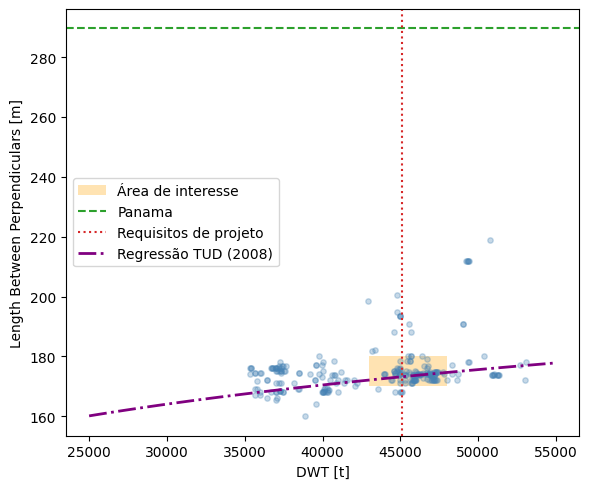

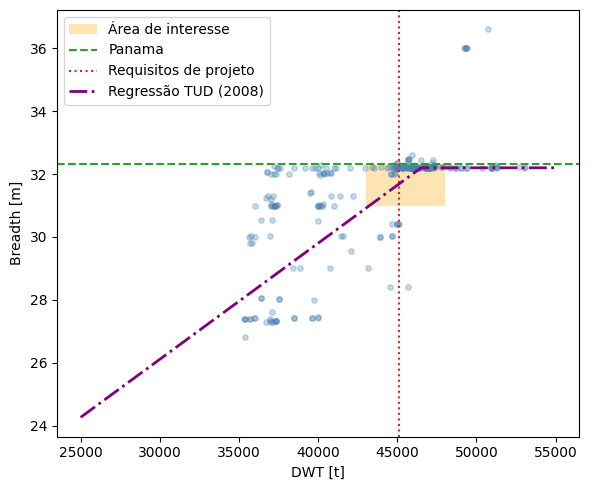

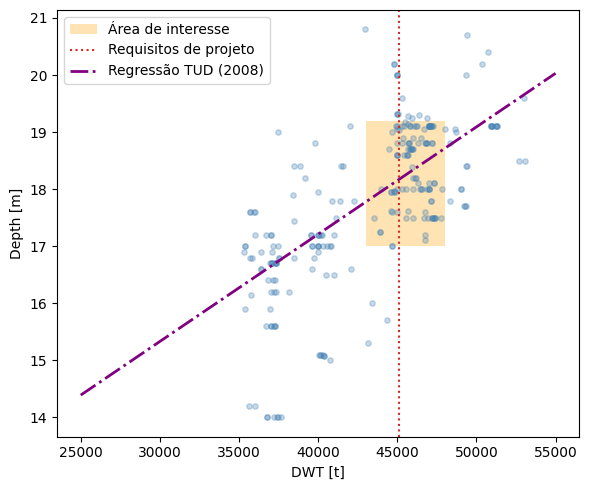

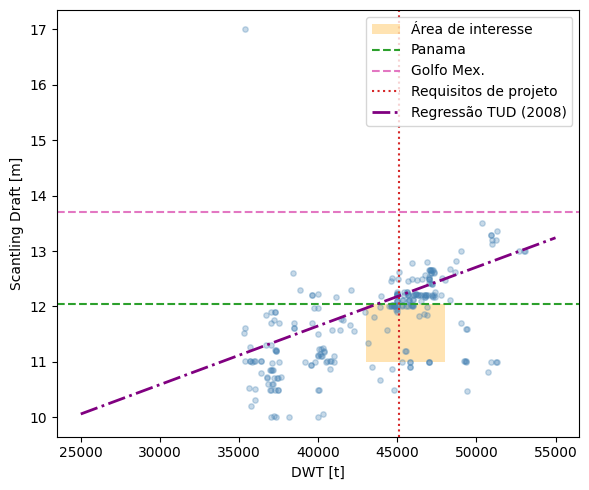

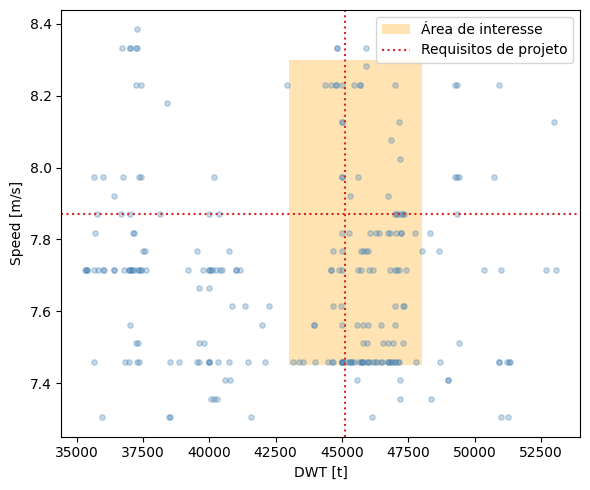

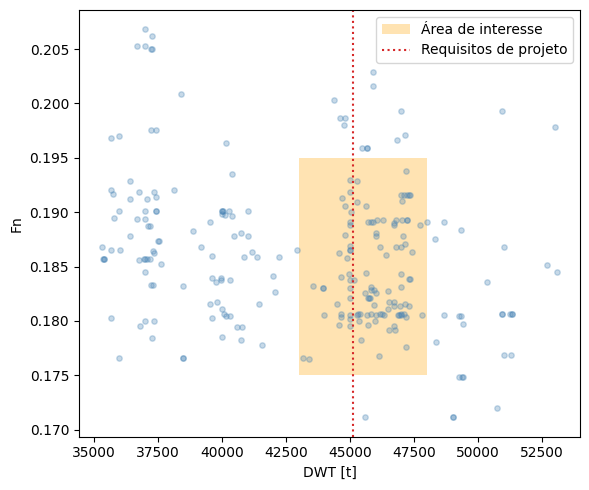

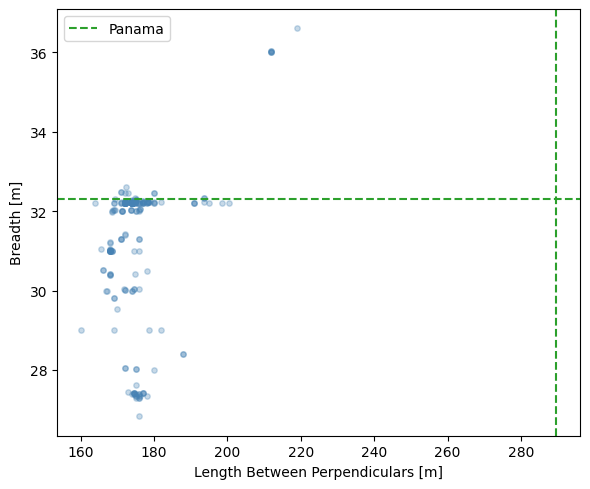

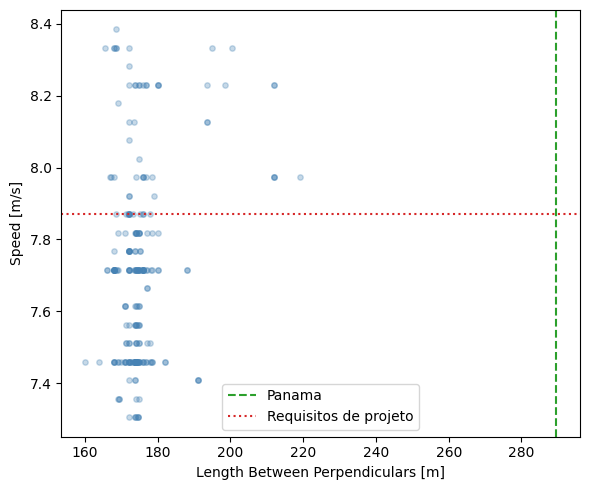

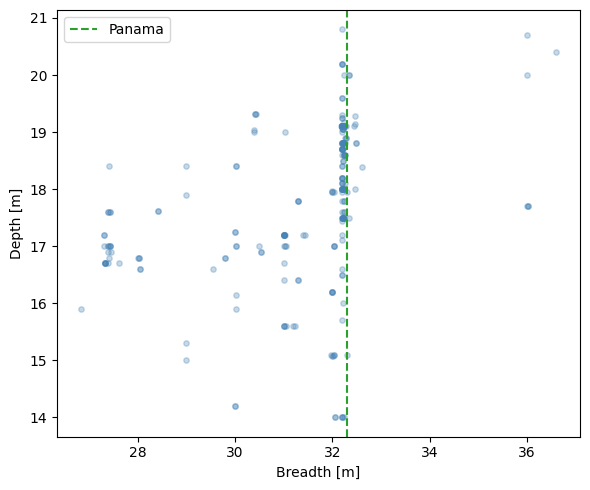

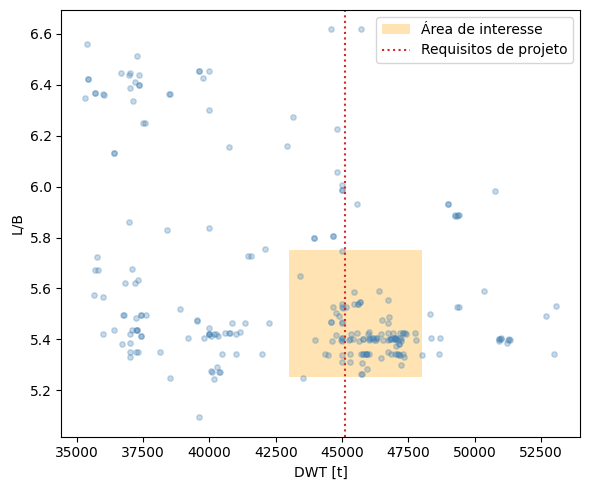

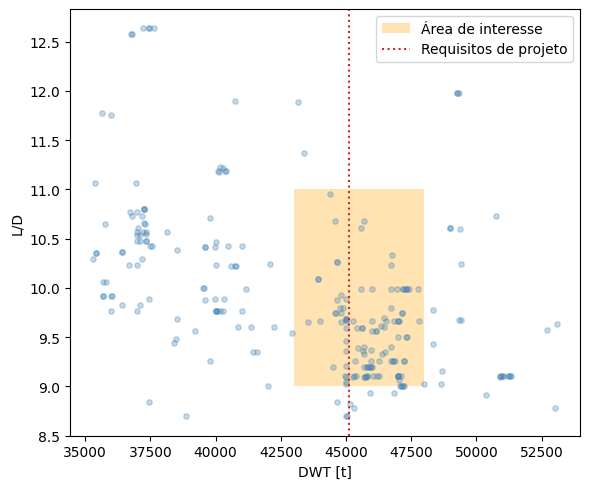

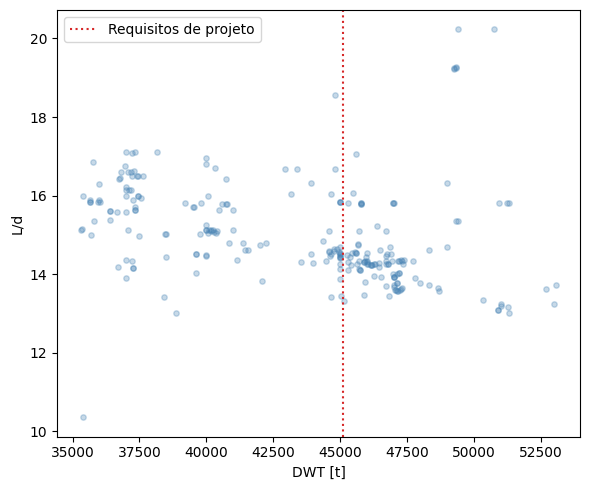

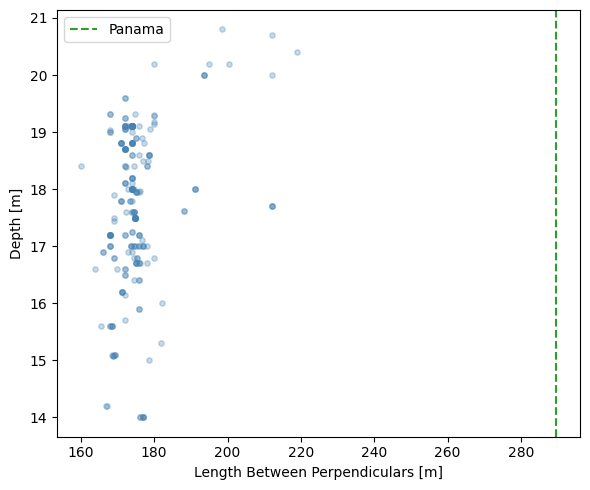

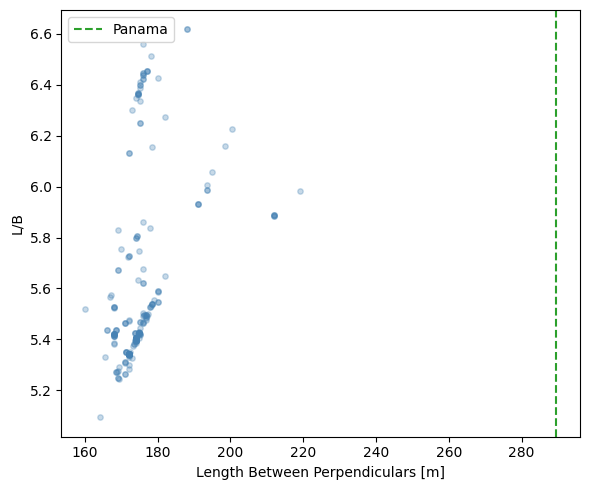

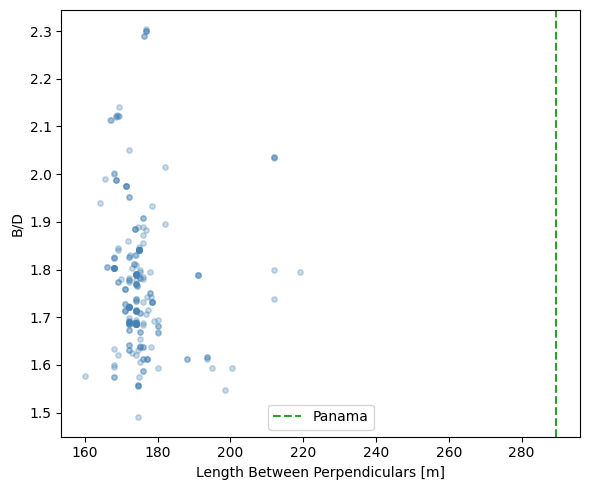

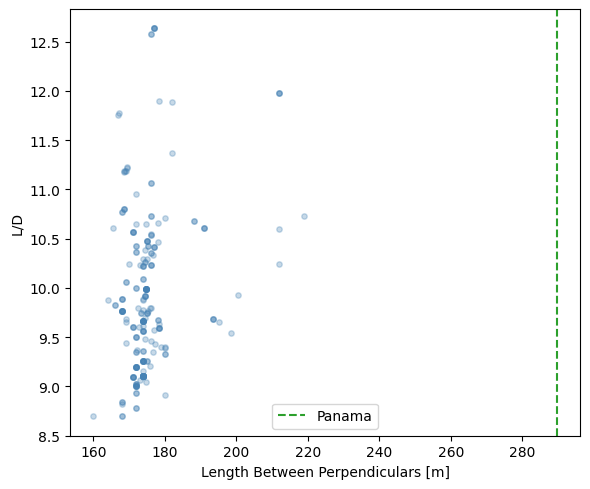

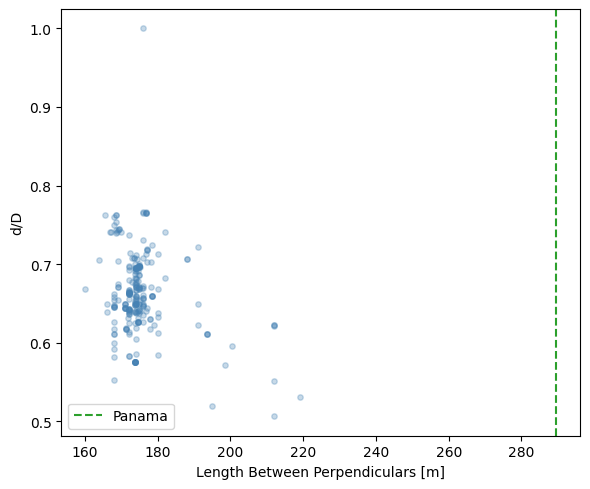

In [80]:
plot_scatter(df_local, SCATTER_PAIRS_LOCAL, reg=False, default_highlight_color="orange")

## Regressão multivariável (LBP em função de DWT e Vs)


In [81]:
def features_from_terms(x1, x2, terms):
    """colunas x1^i * x2^j para cada (i, j) em terms."""
    return np.column_stack([(x1 ** i) * (x2 ** j) for i, j in terms])


def poly_features_2d(x1, x2, degree):
    """colunas x1^i * x2^j para todo i+j <= degree, incluindo o termo constante."""
    terms = [(i, total - i) for total in range(degree + 1) for i in range(total + 1)]
    return features_from_terms(x1, x2, terms), terms


def fit_bivariate_polynomial(x1, x2, y, max_degree=4, r2_threshold=0.95):
    """menor grau total (<= max_degree) que atinge r2_threshold; senao, o de maior R^2.

    x1 e x2 sao padronizados (media 0, desvio 1) antes do ajuste para estabilidade
    numerica, ja que DWT e Vs tem escalas muito diferentes.
    """
    x1_mean, x1_std = x1.mean(), x1.std()
    x2_mean, x2_std = x2.mean(), x2.std()
    x1z = (x1 - x1_mean) / x1_std
    x2z = (x2 - x2_mean) / x2_std

    best = None
    for degree in range(1, max_degree + 1):
        X, terms = poly_features_2d(x1z, x2z, degree)
        coeffs, *_ = np.linalg.lstsq(X, y, rcond=None)
        y_pred = X @ coeffs
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        if best is None or r2 > best["r2"]:
            best = {"degree": degree, "coeffs": coeffs, "terms": terms, "r2": r2}
        if r2 >= r2_threshold:
            break

    best.update(x1_mean=x1_mean, x1_std=x1_std, x2_mean=x2_mean, x2_std=x2_std)
    return best


def fit_polynomial_terms(x1, x2, y, terms):
    """ajusta exatamente os termos (i, j) especificados em terms, sem busca de grau."""
    x1_mean, x1_std = x1.mean(), x1.std()
    x2_mean, x2_std = x2.mean(), x2.std()
    x1z = (x1 - x1_mean) / x1_std
    x2z = (x2 - x2_mean) / x2_std

    X = features_from_terms(x1z, x2z, terms)
    coeffs, *_ = np.linalg.lstsq(X, y, rcond=None)
    y_pred = X @ coeffs
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot

    return {
        "terms": terms, "coeffs": coeffs, "r2": r2,
        "x1_mean": x1_mean, "x1_std": x1_std,
        "x2_mean": x2_mean, "x2_std": x2_std,
    }


def predict_bivariate_polynomial(model, x1, x2):
    x1z = (np.asarray(x1, dtype=float) - model["x1_mean"]) / model["x1_std"]
    x2z = (np.asarray(x2, dtype=float) - model["x2_mean"]) / model["x2_std"]
    X = features_from_terms(x1z, x2z, model["terms"])
    return X @ model["coeffs"]


def format_bivariate_polynomial(model, var1="x1", var2="x2", precision=4):
    """escreve a funcao ajustada em termos das variaveis padronizadas."""
    lines = [
        f"{var1}_z = ({var1} - {model['x1_mean']:.{precision}g}) / {model['x1_std']:.{precision}g}",
        f"{var2}_z = ({var2} - {model['x2_mean']:.{precision}g}) / {model['x2_std']:.{precision}g}",
    ]
    parts = []
    for (i, j), c in zip(model["terms"], model["coeffs"]):
        if i == 0 and j == 0:
            parts.append(f"{c:.{precision}g}")
            continue
        term = ""
        if i:
            term += f"{var1}_z^{i}" if i > 1 else f"{var1}_z"
        if j:
            term += ("*" if term else "") + (f"{var2}_z^{j}" if j > 1 else f"{var2}_z")
        parts.append(f"{c:+.{precision}g}*{term}")
    return "\n".join(lines + ["y = " + " ".join(parts)])


In [82]:
x1 = df["DWT"].to_numpy(dtype=float)
x2 = df["Vs"].to_numpy(dtype=float)
y = df["LBP"].to_numpy(dtype=float)

# LBP = a + b*DWT + c*DWT^2 + d*Vs (sem termo de interacao DWT*Vs nem Vs^2)
LBP_TERMS = [(0, 0), (1, 0), (2, 0), (0, 1)]

lbp_model = fit_polynomial_terms(x1, x2, y, terms=LBP_TERMS)

print(f"R² = {lbp_model['r2']:.4f}")
print(format_bivariate_polynomial(lbp_model, var1="DWT", var2="Vs"))

R² = 0.9652
DWT_z = (DWT - 4.309e+04) / 4.573e+04
Vs_z = (Vs - 7.346) / 0.9628
y = 175.9 +72.37*DWT_z -16.8*DWT_z^2 +11.34*Vs_z


In [83]:
def raw_bivariate_expression(model, var1="x1", var2="x2"):
    """expande o polinomio ajustado (em variaveis padronizadas) de volta para as
    variaveis originais var1, var2 -- usa sympy para a algebra exata das potencias
    e termos cruzados."""
    s1, s2 = sp.symbols(f"{var1} {var2}")
    x1z = (s1 - sp.Float(model["x1_mean"])) / sp.Float(model["x1_std"])
    x2z = (s2 - sp.Float(model["x2_mean"])) / sp.Float(model["x2_std"])
    expr = sum(
        sp.Float(c) * x1z ** i * x2z ** j
        for (i, j), c in zip(model["terms"], model["coeffs"])
    )
    return sp.expand(expr), (s1, s2)


lbp_expr, (DWT_sym, Vs_sym) = raw_bivariate_expression(lbp_model, "DWT", "Vs")
reg_LBP_DWT_Vs = sp.lambdify((DWT_sym, Vs_sym), lbp_expr, modules="numpy")

print(f"LBP = {lbp_expr}")


LBP = -8.03328214913538e-9*DWT**2 + 0.0022750999603707*DWT + 11.778462148958*Vs + 6.26122985125173


In [90]:
DWT_BIN_START = 30000
DWT_BIN_WIDTH = 20000


def dwt_bin_edges(dwt, start=DWT_BIN_START, width=DWT_BIN_WIDTH):
    """limites dos bins ordinais de DWT, cobrindo de -inf a +inf."""
    edges = [-np.inf]
    edge = start
    while edge < dwt.max():
        edges.append(edge)
        edge += width
    edges.append(np.inf)
    return edges


def dwt_bin_labels(edges):
    labels = []
    for lo, hi in itertools.pairwise(edges[:-1], edges[1:]):
        if lo == -np.inf:
            labels.append(f"< {hi:.0f}")
        elif hi == np.inf:
            labels.append(f">= {lo:.0f}")
        else:
            labels.append(f"{lo:.0f}-{hi:.0f}")
    return labels


def make_dwt_bins(dwt, start=DWT_BIN_START, width=DWT_BIN_WIDTH):
    """bins ordinais de DWT: '< start', 'start-...', ..., '>= ultimo limite'."""
    edges = dwt_bin_edges(dwt, start, width)
    return pd.cut(dwt, bins=edges, labels=dwt_bin_labels(edges), right=False)


def discrete_colorscale(colors):
    """colorscale 'em degraus' do plotly: cada cor ocupa uma faixa cheia, sem gradiente."""
    n = len(colors)
    scale = []
    for i, color in enumerate(colors):
        scale.append([i / n, color])
        scale.append([(i + 1) / n, color])
    return scale


In [89]:
dwt_edges = dwt_bin_edges(df["DWT"])
dwt_labels = dwt_bin_labels(dwt_edges)
dwt_bins = make_dwt_bins(df["DWT"])

n_bins = len(dwt_labels)
colors = sample_colorscale("Viridis", [i / max(n_bins - 1, 1) for i in range(n_bins)])

fig = go.Figure()
for color, label in zip(colors, dwt_labels):
    mask = (dwt_bins == label).to_numpy()
    if not mask.any():
        continue
    fig.add_trace(go.Scatter3d(
        x=x1[mask], y=x2[mask], z=y[mask],
        mode="markers",
        marker={"size": 3, "color": color, "opacity": 0.7},
        name=label,
    ))

x1_grid = np.linspace(x1.min(), x1.max(), 200)
x2_grid = np.linspace(x2.min(), x2.max(), 20)
X1g, X2g = np.meshgrid(x1_grid, x2_grid)
Yg = reg_LBP_DWT_Vs(X1g, X2g)

# cor da superficie = faixa de DWT de cada coluna da grade (independe de Vs)
bin_idx_1d = pd.cut(x1_grid, bins=dwt_edges, labels=False, right=False)
surface_color = np.tile(bin_idx_1d, (len(x2_grid), 1)).astype(float) + 0.5

fig.add_trace(go.Surface(
    x=x1_grid, y=x2_grid, z=Yg,
    surfacecolor=surface_color,
    colorscale=discrete_colorscale(colors),
    cmin=0, cmax=n_bins,
    opacity=0.6, showscale=False, name="regressão",
))

fig.update_layout(
    scene={
        "xaxis_title": label_dict.get("DWT", "DWT"),
        "yaxis_title": label_dict.get("Vs", "Vs"),
        "zaxis_title": label_dict.get("LBP", "LBP"),
    },
    title=f"LBP = f(DWT, Vs) — termos {lbp_model['terms']}, R²={lbp_model['r2']:.3f}",
    legend_title="Faixa de DWT",
    height=700,
)

fig.show()


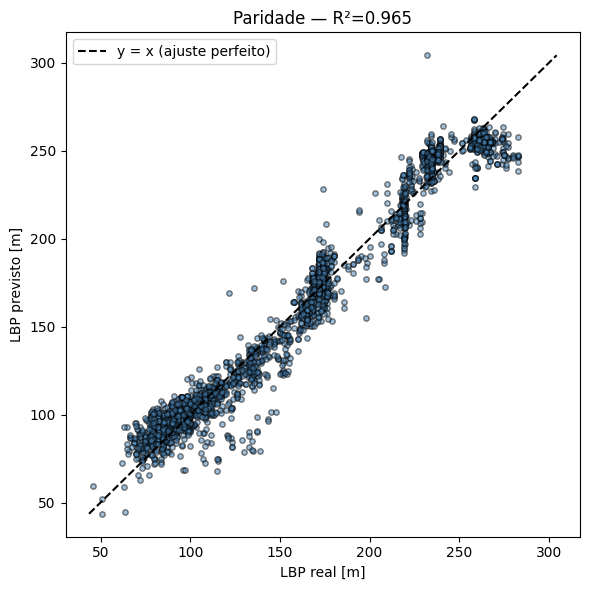

In [86]:
y_pred = reg_LBP_DWT_Vs(x1, x2)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y, y_pred, color="steelblue", edgecolor="black", alpha=0.5, s=15)

lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
ax.plot(lims, lims, color="black", linestyle="--", label="y = x (ajuste perfeito)")

ax.set_xlabel("LBP real [m]")
ax.set_ylabel("LBP previsto [m]")
ax.set_title(f"Paridade — R²={lbp_model['r2']:.3f}")
ax.legend()

plt.tight_layout()
plt.show()


### Análise estatística


In [91]:
numeric_cols = df_local.select_dtypes(include=np.number).columns.tolist()


def mode_of(series):
    m = series.mode()
    return m.iloc[0] if not m.empty else np.nan


stats_rows = {}
for col in numeric_cols:
    s = df_local[col].dropna()
    mean = s.mean()
    std = s.std(ddof=1)
    stats_rows[col] = {
        "media": mean,
        "mediana": s.median(),
        "max": s.max(),
        "min": s.min(),
        "moda": mode_of(s),
        "faixa": s.max() - s.min(),
        "erro padrao": stats.sem(s),
        "variancia": s.var(ddof=1),
        "desv pad": std,
        "coef variancia": std / mean if mean != 0 else np.nan,
        "skewness": stats.skew(s),
        "kurtosis": stats.kurtosis(s),
    }

stats_df = pd.DataFrame(stats_rows)
# stats_df
stats_df.to_csv("ships_dedup_loose_stats.csv", index=True, encoding="latin1")

In [88]:
if False:
    for col in numeric_cols:
        s = df[col].dropna()
        fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(10, 4))
    
        ax_hist.hist(s, bins=50, color="steelblue", edgecolor="black")
        ax_hist.set_xlabel(label_dict.get(col, col))
        ax_hist.set_ylabel("frequencia")
        ax_hist.set_title(f"Histograma - {col}")

        ax_box.boxplot(s, vert=True)
        ax_box.set_ylabel(label_dict.get(col, col))
        ax_box.set_title(f"Boxplot - {col}")
        ax_box.set_xticks([])

        plt.tight_layout()
        #plt.show()